In [ ]:
# --- repo path setup (added during reorg) ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np
import numba as nb

# ============================================================
# Shared Python-side precompute helpers
# ============================================================

def precompute_neighbors_flat(H, W):
    N = H * W
    nbr = np.empty((N, 4), dtype=np.int32)  # 0=N,1=E,2=S,3=W
    for i in range(H):
        im = (i - 1) % H
        ip = (i + 1) % H
        for j in range(W):
            jm = (j - 1) % W
            jp = (j + 1) % W
            k = i * W + j
            nbr[k, 0] = im * W + j
            nbr[k, 1] = i  * W + jp
            nbr[k, 2] = ip * W + j
            nbr[k, 3] = i  * W + jm
    return nbr


def precompute_bond_table(J, patches):
    # B[dir, si, sj] = J[patch(si,dir), patch(sj, opposite(dir))]
    J = np.asarray(J, dtype=np.float64)
    patches = np.asarray(patches, dtype=np.int16)
    n_species = patches.shape[0]
    B = np.empty((4, n_species, n_species), dtype=np.float64)
    for si in range(n_species):
        piN, piE, piS, piW = map(int, patches[si])
        for sj in range(n_species):
            pjN, pjE, pjS, pjW = map(int, patches[sj])
            B[0, si, sj] = J[piN, pjS]
            B[1, si, sj] = J[piE, pjW]
            B[2, si, sj] = J[piS, pjN]
            B[3, si, sj] = J[piW, pjE]
    return B


# ============================================================
# Shared numba helpers
# ============================================================

@nb.njit(cache=True, fastmath=True)
def push_unique(buf, m, x):
    for i in range(m):
        if buf[i] == x:
            return m
    buf[m] = x
    return m + 1


@nb.njit(cache=True, fastmath=True)
def local_energy_k(k, lat, nbr, B):
    s = lat[k]
    n0 = lat[nbr[k, 0]]
    n1 = lat[nbr[k, 1]]
    n2 = lat[nbr[k, 2]]
    n3 = lat[nbr[k, 3]]
    return 0.5 * (B[0, s, n0] + B[1, s, n1] + B[2, s, n2] + B[3, s, n3])


@nb.njit(cache=True, fastmath=True)
def list_add(loc, lst, length, k):
    if loc[k] != -1:
        return length
    loc[k] = length
    lst[length] = k
    return length + 1


@nb.njit(cache=True, fastmath=True)
def list_discard(loc, lst, length, k):
    idx = loc[k]
    if idx == -1:
        return length
    last = lst[length - 1]
    lst[idx] = last
    loc[last] = idx
    loc[k] = -1
    return length - 1


@nb.njit(cache=True, fastmath=True)
def record_sample_numba(
    si,
    energy,
    energies_s,
    dens_mode,
    dens_s,
    counts,
    invA,
    site_mode,
    site_s,
    e_sites,
    n_species,
    N
):
    energies_s[si] = energy
    if dens_mode != 0:
        if dens_mode == 1:
            dens_s[si, 0] = counts[n_species - 1] * invA
        else:
            for s in range(n_species):
                dens_s[si, s] = counts[s] * invA
    if site_mode == 2:
        for k in range(N):
            site_s[si, k] = e_sites[k]


# ============================================================
# Version D: 9 species (0..8), identity set 0..7 only
# ============================================================

def precompute_candidates_07():
    cand07 = np.empty((8, 7), dtype=np.int16)
    for s in range(8):
        t = 0
        for x in range(8):
            if x != s:
                cand07[s, t] = x
                t += 1
    return cand07


@nb.njit(cache=True, fastmath=True)
def update_membership_site_9(k, lat, grand_loc, grand_list, grand_len):
    s = lat[k]
    if s < 8:
        grand_len = list_add(grand_loc, grand_list, grand_len, k)
    else:
        grand_len = list_discard(grand_loc, grand_list, grand_len, k)
    return grand_len


@nb.njit(cache=True, fastmath=True)
def mc_kernel_9(
    lat2d, nbr, B, mu, cand07,
    simulation_steps, burn_in_steps, sample_interval,
    dens_mode, site_mode,
    beta, p_swap, p_id07
):
    H, W = lat2d.shape
    N = H * W
    n_species = mu.shape[0]
    invA = 1.0 / N

    lat = lat2d.ravel().copy()

    counts = np.zeros(n_species, dtype=np.int64)
    for k in range(N):
        counts[lat[k]] += 1

    grand_loc  = np.full(N, -1, dtype=np.int32)
    grand_list = np.empty(N, dtype=np.int32)
    grand_len = 0
    for k in range(N):
        s = lat[k]
        if s < 8:
            grand_loc[k] = grand_len
            grand_list[grand_len] = k
            grand_len += 1
        # s==8 is canonical

    e_sites = np.empty(N, dtype=np.float64)
    energy = 0.0
    for k in range(N):
        v = local_energy_k(k, lat, nbr, B)
        e_sites[k] = v
        energy += v

    acc_try = np.zeros(2, dtype=np.int64)
    acc_ok  = np.zeros(2, dtype=np.int64)

    buf10 = np.empty(10, dtype=np.int32)
    old10 = np.empty(10, dtype=np.float64)
    buf5  = np.empty(5, dtype=np.int32)
    old5  = np.empty(5, dtype=np.float64)

    tail_len = simulation_steps - burn_in_steps
    if tail_len < 0:
        tail_len = 0
    n_samples = tail_len // sample_interval + 1

    energies_s = np.empty(n_samples, dtype=np.float64)

    if dens_mode == 2:
        dens_s = np.empty((n_samples, n_species), dtype=np.float64)
    elif dens_mode == 1:
        dens_s = np.empty((n_samples, 1), dtype=np.float64)
    else:
        dens_s = np.empty((0, 0), dtype=np.float64)

    if site_mode == 2:
        site_s = np.empty((n_samples, N), dtype=np.float32)
    elif site_mode == 1:
        site_s = np.empty((1, N), dtype=np.float32)
    else:
        site_s = np.empty((0, 0), dtype=np.float32)

    # burn-in
    for _ in range(burn_in_steps):
        r = np.random.rand()

        if r < p_swap:
            acc_try[0] += 1
            k1 = np.random.randint(N)
            k2 = np.random.randint(N - 1)
            if k2 >= k1:
                k2 += 1

            s1 = lat[k1]
            s2 = lat[k2]
            if s1 != s2:
                m = 0
                m = push_unique(buf10, m, k1)
                m = push_unique(buf10, m, k2)
                for d in range(4):
                    m = push_unique(buf10, m, nbr[k1, d])
                for d in range(4):
                    m = push_unique(buf10, m, nbr[k2, d])

                for t in range(m):
                    kk = buf10[t]
                    old10[t] = e_sites[kk]

                lat[k1] = s2
                lat[k2] = s1

                dE = 0.0
                for t in range(m):
                    kk = buf10[t]
                    newv = local_energy_k(kk, lat, nbr, B)
                    dE += (newv - old10[t])
                    e_sites[kk] = newv

                if (dE <= 0.0) or (np.random.rand() < np.exp(-beta * dE)):
                    energy += dE
                    grand_len = update_membership_site_9(k1, lat, grand_loc, grand_list, grand_len)
                    grand_len = update_membership_site_9(k2, lat, grand_loc, grand_list, grand_len)
                    acc_ok[0] += 1
                else:
                    lat[k1] = s1
                    lat[k2] = s2
                    for t in range(m):
                        kk = buf10[t]
                        e_sites[kk] = old10[t]

        else:
            if grand_len > 0:
                k = grand_list[np.random.randint(grand_len)]
                s = lat[k]
                if s >= 8:
                    grand_len = update_membership_site_9(k, lat, grand_loc, grand_list, grand_len)
                    continue

                acc_try[1] += 1
                new_s = cand07[s, np.random.randint(7)]

                m = 0
                m = push_unique(buf5, m, k)
                for d in range(4):
                    m = push_unique(buf5, m, nbr[k, d])

                for t in range(m):
                    kk = buf5[t]
                    old5[t] = e_sites[kk]

                lat[k] = new_s

                dE = 0.0
                for t in range(m):
                    kk = buf5[t]
                    newv = local_energy_k(kk, lat, nbr, B)
                    dE += (newv - old5[t])
                    e_sites[kk] = newv

                dPhi = dE - (mu[new_s] - mu[s])
                if (dPhi <= 0.0) or (np.random.rand() < np.exp(-beta * dPhi)):
                    energy += dE
                    counts[s] -= 1
                    counts[new_s] += 1
                    acc_ok[1] += 1
                else:
                    lat[k] = s
                    for t in range(m):
                        kk = buf5[t]
                        e_sites[kk] = old5[t]

    # tail + sampling
    si = 0
    record_sample_numba(
        si, energy, energies_s,
        dens_mode, dens_s, counts, invA,
        site_mode, site_s, e_sites,
        n_species, N
    )
    si += 1

    for t in range(1, tail_len + 1):
        r = np.random.rand()

        if r < p_swap:
            acc_try[0] += 1
            k1 = np.random.randint(N)
            k2 = np.random.randint(N - 1)
            if k2 >= k1:
                k2 += 1

            s1 = lat[k1]
            s2 = lat[k2]
            if s1 != s2:
                m = 0
                m = push_unique(buf10, m, k1)
                m = push_unique(buf10, m, k2)
                for d in range(4):
                    m = push_unique(buf10, m, nbr[k1, d])
                for d in range(4):
                    m = push_unique(buf10, m, nbr[k2, d])

                for tt in range(m):
                    kk = buf10[tt]
                    old10[tt] = e_sites[kk]

                lat[k1] = s2
                lat[k2] = s1

                dE = 0.0
                for tt in range(m):
                    kk = buf10[tt]
                    newv = local_energy_k(kk, lat, nbr, B)
                    dE += (newv - old10[tt])
                    e_sites[kk] = newv

                if (dE <= 0.0) or (np.random.rand() < np.exp(-beta * dE)):
                    energy += dE
                    grand_len = update_membership_site_9(k1, lat, grand_loc, grand_list, grand_len)
                    grand_len = update_membership_site_9(k2, lat, grand_loc, grand_list, grand_len)
                    acc_ok[0] += 1
                else:
                    lat[k1] = s1
                    lat[k2] = s2
                    for tt in range(m):
                        kk = buf10[tt]
                        e_sites[kk] = old10[tt]

        else:
            if grand_len > 0:
                k = grand_list[np.random.randint(grand_len)]
                s = lat[k]
                if s >= 8:
                    grand_len = update_membership_site_9(k, lat, grand_loc, grand_list, grand_len)
                    continue

                acc_try[1] += 1
                new_s = cand07[s, np.random.randint(7)]

                m = 0
                m = push_unique(buf5, m, k)
                for d in range(4):
                    m = push_unique(buf5, m, nbr[k, d])

                for tt in range(m):
                    kk = buf5[tt]
                    old5[tt] = e_sites[kk]

                lat[k] = new_s

                dE = 0.0
                for tt in range(m):
                    kk = buf5[tt]
                    newv = local_energy_k(kk, lat, nbr, B)
                    dE += (newv - old5[tt])
                    e_sites[kk] = newv

                dPhi = dE - (mu[new_s] - mu[s])
                if (dPhi <= 0.0) or (np.random.rand() < np.exp(-beta * dPhi)):
                    energy += dE
                    counts[s] -= 1
                    counts[new_s] += 1
                    acc_ok[1] += 1
                else:
                    lat[k] = s
                    for tt in range(m):
                        kk = buf5[tt]
                        e_sites[kk] = old5[tt]

        if (t % sample_interval == 0) and (si < n_samples):
            record_sample_numba(
                si, energy, energies_s,
                dens_mode, dens_s, counts, invA,
                site_mode, site_s, e_sites,
                n_species, N
            )
            si += 1

    if site_mode == 1:
        for k in range(N):
            site_s[0, k] = e_sites[k]

    return energies_s[:si], dens_s[:si], site_s, acc_try, acc_ok, lat.reshape(H, W)


def simulate_single_box_numba_9(
    lattice_int, J, patches, mu_table,
    simulation_steps=1_000_000, beta=1.0,
    burn_in_steps=0, sample_interval=200_000,
    record_densities="all",
    record_site_energies="all",
    move_probs=(0.5, 0.5),
):
    lattice_int = np.asarray(lattice_int, dtype=np.int16)
    H, W = lattice_int.shape

    mu_table = np.asarray(mu_table, dtype=np.float64)
    patches = np.asarray(patches, dtype=np.int16)

    if mu_table.shape[0] != patches.shape[0]:
        raise ValueError("mu_table and patches must have same length (n_species).")
    if mu_table.shape[0] != 9:
        raise ValueError("This implementation is specialized to n_species=9 (0..8).")
    if lattice_int.min() < 0 or lattice_int.max() >= 9:
        raise ValueError("lattice_int contains out-of-range labels for n_species=9.")

    nbr = precompute_neighbors_flat(H, W)
    B = precompute_bond_table(J, patches)
    cand07 = precompute_candidates_07()

    if record_densities == "all":
        dens_mode = 2
    elif record_densities == "last":
        dens_mode = 1
    else:
        dens_mode = 0

    if record_site_energies == "all":
        site_mode = 2
    elif record_site_energies == "last":
        site_mode = 1
    else:
        site_mode = 0

    p_swap, p_id07 = move_probs
    if not np.isclose(p_swap + p_id07, 1.0):
        raise ValueError("move_probs must sum to 1")

    E_s, D_s, site_flat, acc_try, acc_ok, lat_final = mc_kernel_9(
        lattice_int, nbr, B, mu_table, cand07,
        int(simulation_steps), int(burn_in_steps), int(sample_interval),
        int(dens_mode), int(site_mode),
        float(beta), float(p_swap), float(p_id07)
    )

    D = None if D_s.size == 0 else D_s
    siteE = None if site_flat.size == 0 else site_flat.reshape(site_flat.shape[0], H, W)

    acc_stats = {
        "tries":   {"swap": int(acc_try[0]), "ident_0_7": int(acc_try[1])},
        "accepts": {"swap": int(acc_ok[0]),  "ident_0_7": int(acc_ok[1])},
        "rates":   {
            "swap":      float(acc_ok[0] / acc_try[0] if acc_try[0] else 0.0),
            "ident_0_7": float(acc_ok[1] / acc_try[1] if acc_try[1] else 0.0),
        },
    }

    return E_s, D, siteE, acc_stats, lat_final
def loess_smooth_logpdf(x, y, frac=0.25, it=0):
    """
    Smooth a 1D PDF y(x) by applying LOESS to log(y) where y>0.
    Returns an array of the same shape as y.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    out = np.zeros_like(y)

    mask = y > 0
    if mask.sum() < 5:   # not enough points; bail out
        return y.copy()

    # x[mask] is already sorted (centers), lowess returns sorted by x
    xy = lowess(np.log(y[mask]), x[mask], frac=frac, it=it, return_sorted=True)
    # xy[:,0] are the x's, xy[:,1] are smoothed log(y)
    out[mask] = np.exp(xy[:, 1])
    return out
def make_density_edges(m, V, k=1):
    """Fixed bin edges aligned to the discrete grid m = integer/V.
       k aggregates k adjacent discrete levels; binwidth = k/V."""
    bw = k / V
    m_int_min = int(np.floor(m.min() * V))
    m_int_max = int(np.ceil (m.max() * V))
    # edges at (integer - 0.5)/V so each bin is centered on integer/V
    edges = (np.arange(m_int_min - 0.5, m_int_max + 1.5, k)) / V
    return edges, bw

# ---- weighted histogram with given edges (μ-reweighting) ----

# ---------- your reweight histogram (kept as-is) ----------
def weighted_hist_with_edges(m, counts, dmu_vec, edges, beta=1.0):
    m = np.asarray(m, float)
    counts = np.asarray(counts, float)
    dmu_vec = np.asarray(dmu_vec, float)
    print(counts.shape, dmu_vec.shape)
    logw = beta * (counts @ dmu_vec)
    logw -= np.max(logw)
    w = np.exp(logw)

    H, _ = np.histogram(m, bins=edges, weights=w, density=True)
    Neff = (w.sum() ** 2) / np.sum(w ** 2)
    return H, edges, w, Neff
# ---------- load baseline ----------
def load_baseline_hist(path):
    with open(path, "r") as f:
        data = json.load(f)

    centers = np.asarray(data["centers"], dtype=float)
    H0 = np.asarray(data["H_smooth"], dtype=float)  # baseline smooth PDF
    bw = float(data["binwidth"])
    m = np.asarray(data["m"], dtype=float)
    counts = np.asarray(data["counts"], dtype=float)
    # reconstruct edges consistent with centers + binwidth
    edges = np.concatenate([centers - 0.5 * bw, [centers[-1] + 0.5 * bw]])
    return centers, H0, edges, bw, data,m, counts




# ---------- load + reweight + (optional) save + plot ----------
def load_and_reweight(baseline_json_path, dmu_vec,
                      beta=1.0,
                      save_path=None,
                      do_plot=True):
    centers0, H0_smooth, edges, binwidth, meta0,m,counts = load_baseline_hist(baseline_json_path)

    H_rw, edges_rw, w, Neff_rw = weighted_hist_with_edges(
        m=m, counts=counts, dmu_vec=dmu_vec, edges=edges, beta=beta
    )

    centers_rw = 0.5 * (edges_rw[:-1] + edges_rw[1:])

    if save_path is not None:
        out = {
            "baseline_file": baseline_json_path,
            "centers": centers_rw.tolist(),
            "H_reweighted": H_rw.tolist(),
            "binwidth": float(binwidth),
            "Neff_reweighted": float(Neff_rw),
            "beta": float(beta),
            "dmu_vec": np.asarray(dmu_vec, float).tolist(),
        }
        with open(save_path, "w") as f:
            json.dump(out, f, indent=2)

    if do_plot:
        plt.plot(centers0, H0_smooth, label="baseline H_smooth")
        plt.plot(centers_rw, H_rw, label="reweighted")
        plt.xlabel("m")
        plt.ylabel("pdf")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return centers_rw, H_rw, Neff_rw, w

class Particle:
    def __init__(self,index,patches=[],mu=0):
        self.patches=patches
        self.mu=mu
        self.index=index
        
    def get(self,i):
        return self.patches[i]
    def set_mu(self,mu):
        self.mu=mu
def get_species_list_ind(species):


    letter_to_index = {}  # mapping from letter to unique integer index
    next_index = 1
    particles = []
    letter_to_index['0']=0
    ind=0
    for s in species:
        n = len(s)
        # Create a base patch array of length 4 filled with zeros (0 means "no $
        base_array = np.zeros(4, dtype=int)
        # Right-align the string: fill positions 4 - n to 3 with the correspond$
        for i, letter in enumerate(s):
            if letter not in letter_to_index:
                letter_to_index[letter] = next_index
                next_index += 1
            base_array[4 - n + i] = letter_to_index[letter]
       
        
        # Generate all four rotations of the base array.
        unique_rotations = set()
        rotation_list = []  # to preserve an order (if needed)
        for r in range(4):
            rotated = np.roll(base_array, -r)  # rotate left by r positions
            tup = tuple(rotated.tolist())
            if tup not in unique_rotations:
                unique_rotations.add(tup)
                rotation_list.append(rotated)
        
        # For each distinct rotation, create a Particle object.
        for rot in rotation_list:
            particles.append(Particle(ind,patches=np.array(rot)))
            ind+=1
    
    return particles

In [17]:

species=get_species_list_ind(['ABEF','BAEF','SSSS'])
species_grand=species[:8]
def to_int_lattice(lat): 
    lat = np.asarray(lat) 
    if np.issubdtype(lat.dtype, np.integer): 
        return lat.astype(np.int64, copy=False) 
    return np.vectorize(lambda p: species.index(p), otypes=[np.int64])(lat)
L = 20
N_total = L * L
n = len(species)
chem_pots = np.zeros(n)

J=np.zeros((6,6))
J[1,3]=-3
J[2,4]= -3
J[3,3]=-1; J[4,4]=-1





(48020, 9) (9,)
(48020, 9) (9,)


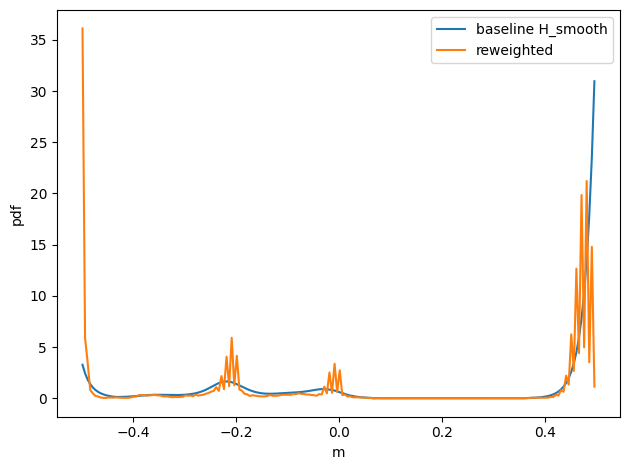

(48020, 9) (9,)
(48020, 9) (9,)


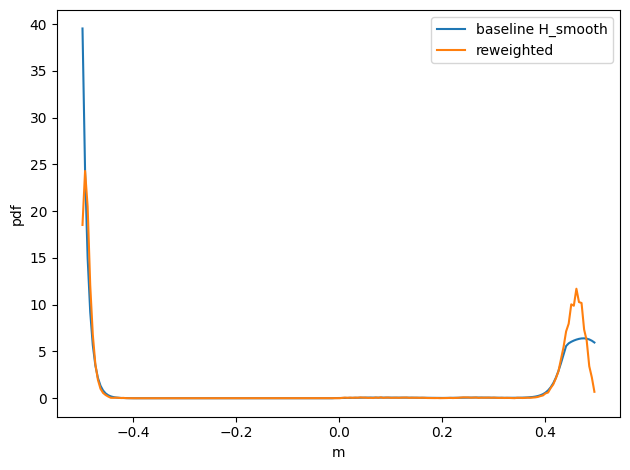

(48020, 9) (9,)
(48020, 9) (9,)


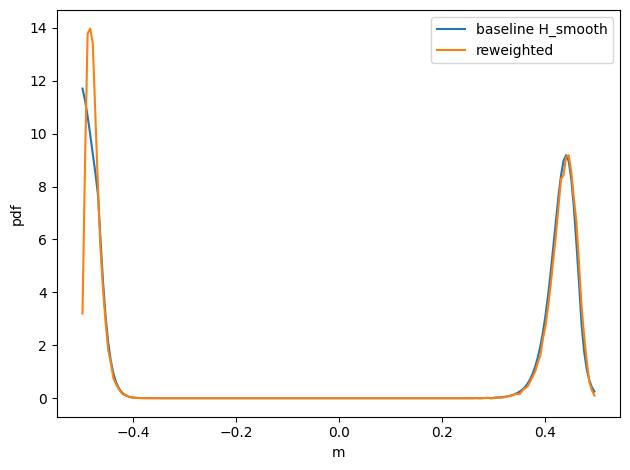

(48020, 9) (9,)
(48020, 9) (9,)


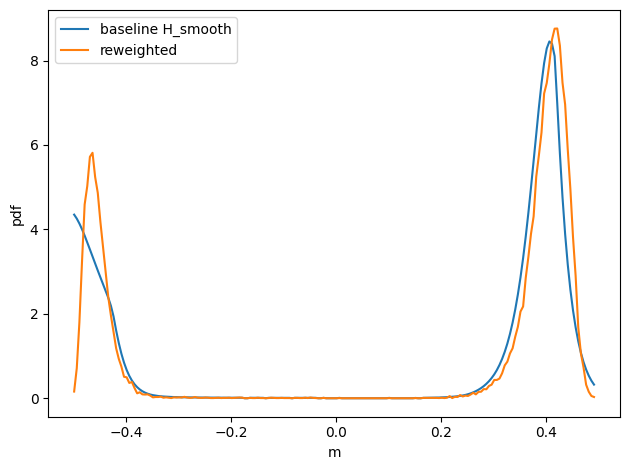

(48020, 9) (9,)
(48020, 9) (9,)


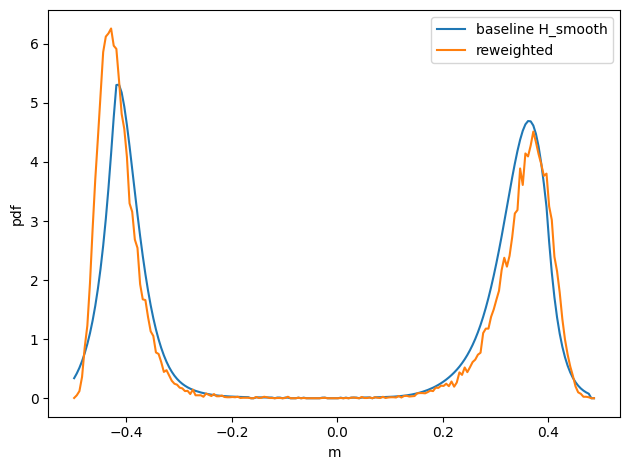

(48020, 9) (9,)
(48020, 9) (9,)


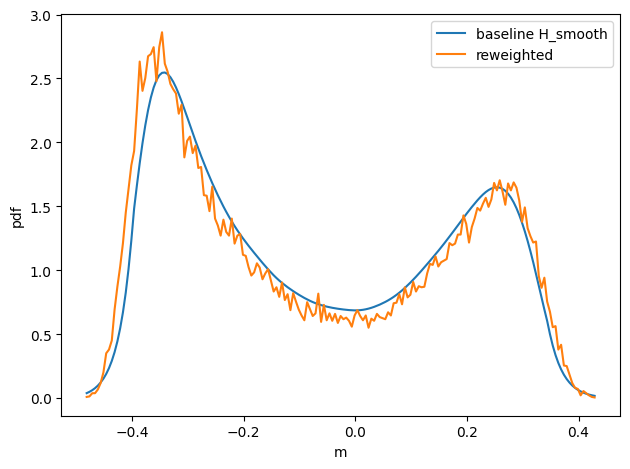

(48020, 9) (9,)
(48020, 9) (9,)


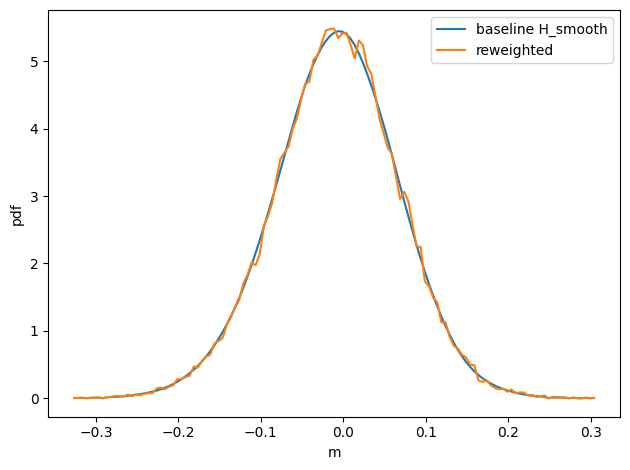

(48020, 9) (9,)
(48020, 9) (9,)


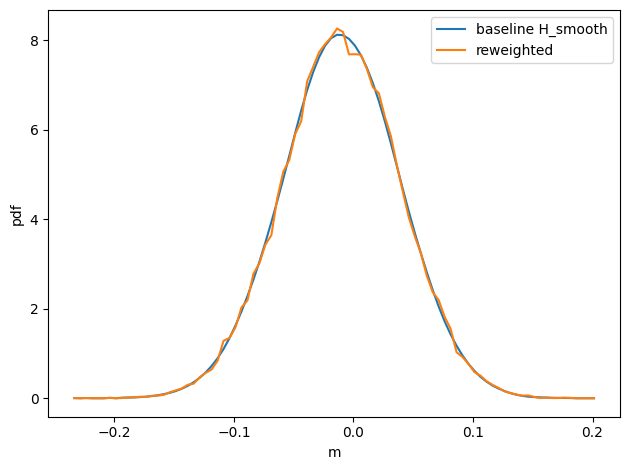

In [19]:
Ts=[0.5,0.6,0.7,0.8,0.9,1,1.1,1.2]
for T in Ts:
    rho_middle = np.array([0.25/4]*4+[0.25/4]*4+[0.5])
    rho_middle /= rho_middle.sum()
    N_middle = [int(r * N_total) for r in rho_middle]
    N_middle[0] += N_total - sum(N_middle)
    flat = []; [flat.extend([species[i]]*N_middle[i]) for i in range(len(rho_middle))]
    np.random.shuffle(flat)
    lattice_middle = np.array(flat).reshape((L, L))
    lattice_idx = np.array([[cell.index for cell in row] for row in lattice_middle], dtype=np.int64)
    

    V = L * L  # here V=100
    mu_table=np.zeros(9)
    mu_table[:4]= 0.042
    J_T=(J+J.T)/T

    E_runs = []
    R_runs = []

    for i in range(20):

        np.random.shuffle(flat)
        lattice_middle = np.array(flat).reshape((L, L))
        lattice_int=to_int_lattice(lattice_middle)
        E_s, D_s, acc_stats, ac_stats,lat_final = simulate_single_box_numba_9(
            lattice_int, J_T, np.array([p.patches for p in species]),mu_table,
            simulation_steps=200_000_000, beta=1.0, burn_in_steps=80_000_000,
            sample_interval=50_000,            # << sampling done inside
            record_densities="all",             # or "last" to save more memory
            move_probs=(0.5, 0.5)
        )
        E_runs.append(E_s)
        if D_s is not None:
            R_runs.append(D_s)
    all_energies  = np.concatenate(E_runs, axis=0)
    all_densities = np.vstack(R_runs)
    S, n_species  = all_densities.shape
    from statsmodels.nonparametric.smoothers_lowess import lowess

    weak     = np.sum(all_densities[:, :4],  axis=1)
    dominant = np.sum(all_densities[:, 4:8], axis=1)
    m = dominant - weak                        # OP in density units
    counts = (all_densities * V)               # per-sample counts
    # fixed edges: binwidth = 1/V (set k=2 for coarser 0.02 if desired)
    edges, binwidth = make_density_edges(m, V, k=2)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # ---------- reweight and plot for target μ' with LOESS smoothing ----------

    dmu_zero = np.zeros(9)
    H0, edges_out, w0, Neff0 = weighted_hist_with_edges(
         m, counts, dmu_zero, edges, beta=1
    )

    H0_smooth = loess_smooth_logpdf(centers, H0, frac=0.2)

    # renormalize
    norm0 = np.sum(H0_smooth * binwidth)
    if norm0 > 0:
        H0_smooth /= norm0

    # save to json
    data = {
        "centers": centers.tolist(),
        'm': m.tolist(),
        'counts': counts.tolist(),
        "H_smooth": H0_smooth.tolist(),
        "binwidth": float(binwidth),
        "Neff": float(Neff0),
        "frac_hist": float(0.1),

    }
    with open(f"../data/baseline_hist_big_T{T:0.1f}_mu0042.json", "w") as f:
        json.dump(data, f, indent=2)


    dmu_vec = np.zeros(9)
    dmu_vec[:4] +=  0

    centers_rw, H_rw, Neff_rw, w = load_and_reweight(
         baseline_json_path=f"../data/baseline_hist_big_T{T:0.1f}_mu0042.json",
         dmu_vec=dmu_vec,
         beta=1.0,
         do_plot=True
     )
